In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

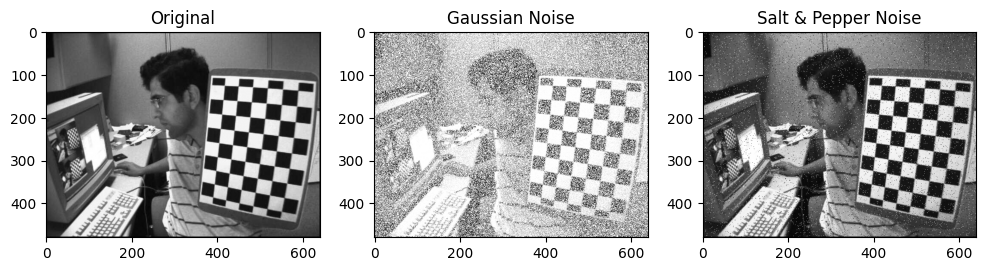

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def add_gaussian_noise(image, mean=0, sigma=25):
    """افزودن نویز گوسی"""
    gaussian = np.random.normal(mean, sigma, image.shape).astype('uint8')
    noisy_image = cv2.add(image, gaussian)
    return noisy_image

def add_salt_and_pepper_noise(image, salt_prob, pepper_prob):
    """افزودن نویز نمک و فلفل"""
    noisy_image = np.copy(image)
    
    # افزودن نمک (پیکسل‌های سفید)
    num_salt = np.ceil(salt_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy_image[tuple(coords)] = 255
    
    # افزودن فلفل (پیکسل‌های سیاه)
    num_pepper = np.ceil(pepper_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy_image[tuple(coords)] = 0
    
    return noisy_image

# ۱. بارگذاری تصویر
# (یک تصویر سیاه و سفید دلخواه جایگزین کنید)
img = cv2.imread('left06.jpg', cv2.IMREAD_GRAYSCALE)

if img is not None:
    # ۲. ایجاد نویزها
    gaussian_img = add_gaussian_noise(img)
    sp_img = add_salt_and_pepper_noise(img, 0.02, 0.02) # احتمال ۲ درصد نمک و ۲ درصد فلفل

    # ۳. نمایش نتایج
    plt.figure(figsize=(12, 4))
    plt.subplot(131), plt.imshow(img, cmap='gray'), plt.title('Original')
    plt.subplot(132), plt.imshow(gaussian_img, cmap='gray'), plt.title('Gaussian Noise')
    plt.subplot(133), plt.imshow(sp_img, cmap='gray'), plt.title('Salt & Pepper Noise')
    plt.show()
else:
    print("لطفاً فایل تصویر را چک کنید.")


In [2]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

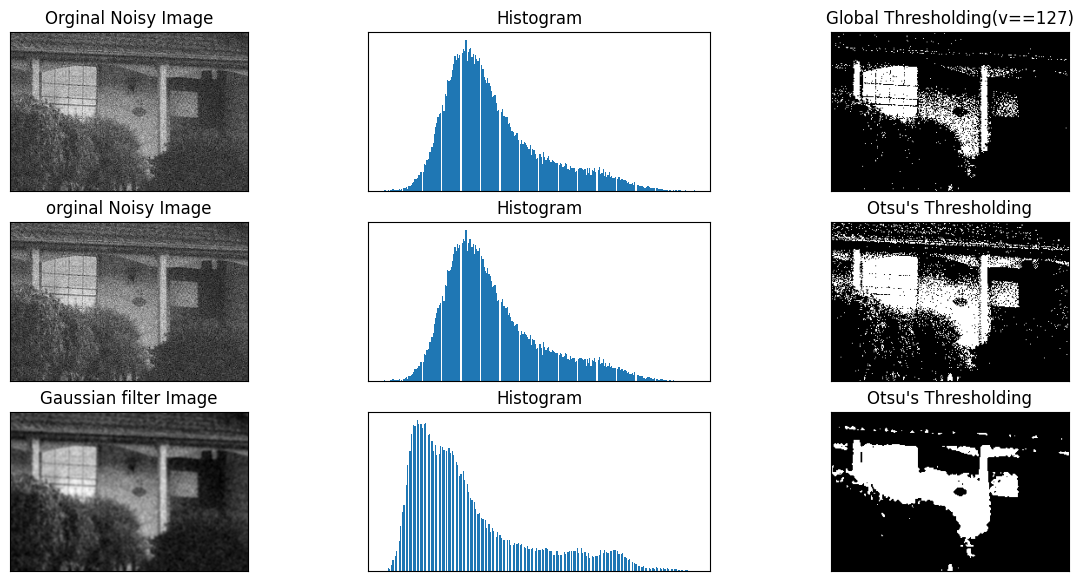

In [3]:
#متغیر img یک ماتریس NumPy است.
img=cv.imread("noise.jpg",0)
ret1,th1=cv.threshold(img,127,255,cv.THRESH_BINARY)

ret2,th2=cv.threshold(img,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)

blur=cv.GaussianBlur(img,(5,5),0)

ret3,th3=cv.threshold(blur,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
images=[img,0,th1,
        img,0,th2,
        blur,0,th3]
titles=['Orginal Noisy Image','Histogram','Global Thresholding(v==127)','orginal Noisy Image','Histogram',
        "Otsu's Thresholding","Gaussian filter Image","Histogram","Otsu's Thresholding"]



plt.figure(figsize=[15,7])
for i in range(3):
    plt.subplot(3,3,i*3+1),plt.imshow(images[i*3],'gray'),
    plt.title(titles[i*3]),plt.xticks([]),plt.yticks([])

    plt.subplot(3,3,i*3+2),plt.hist(images[i*3].ravel(),256)
    plt.title(titles[i*3+1]),plt.xticks([]),plt.yticks([])

    plt.subplot(3,3,i*3+3),plt.imshow(images[i*3+2],'gray')
    plt.title(titles[i*3+2]),plt.xticks([]),plt.yticks([])
plt.show()

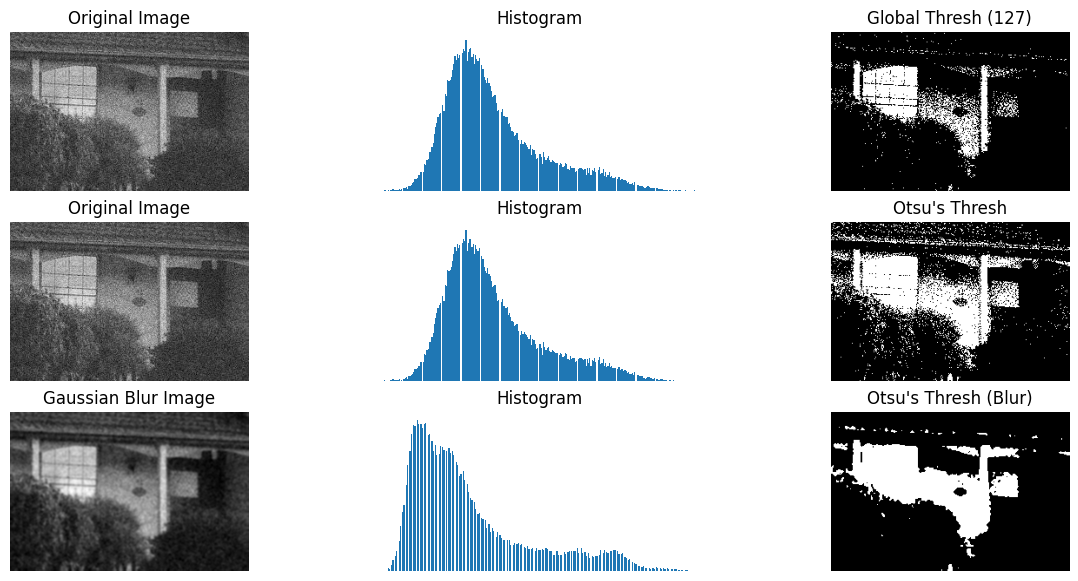

In [4]:
import cv2 as cv
import matplotlib.pyplot as plt

# 1. خواندن تصویر و انجام پردازش‌ها
img = cv.imread("noise.jpg", 0)
blur = cv.GaussianBlur(img, (5, 5), 0)

# محاسبه سه نوع Threshold
ret1, th1 = cv.threshold(img, 127, 255, cv.THRESH_BINARY)
ret2, th2 = cv.threshold(img, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
ret3, th3 = cv.threshold(blur, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

# 2. نمایش نتایج (به صورت کاملاً دستی و شفاف)
plt.figure(figsize=[15, 7])

# ردیف اول: Threshold ساده
plt.subplot(3, 3, 1); plt.imshow(img, 'gray'); plt.title('Original Image'); plt.axis('off')
plt.subplot(3, 3, 2); plt.hist(img.ravel(), 256); plt.title('Histogram'); plt.axis('off')
plt.subplot(3, 3, 3); plt.imshow(th1, 'gray'); plt.title('Global Thresh (127)'); plt.axis('off')

# ردیف دوم: Otsu روی تصویر اصلی
plt.subplot(3, 3, 4); plt.imshow(img, 'gray'); plt.title('Original Image'); plt.axis('off')
plt.subplot(3, 3, 5); plt.hist(img.ravel(), 256); plt.title('Histogram'); plt.axis('off')
plt.subplot(3, 3, 6); plt.imshow(th2, 'gray'); plt.title("Otsu's Thresh"); plt.axis('off')

# ردیف سوم: Otsu روی تصویر Blur شده
plt.subplot(3, 3, 7); plt.imshow(blur, 'gray'); plt.title('Gaussian Blur Image'); plt.axis('off')
plt.subplot(3, 3, 8); plt.hist(blur.ravel(), 256); plt.title('Histogram'); plt.axis('off')
plt.subplot(3, 3, 9); plt.imshow(th3, 'gray'); plt.title("Otsu's Thresh (Blur)"); plt.axis('off')

plt.show()
